In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from timm.layers import DropPath, PatchEmbed

In [2]:
# Vanilla Network

class Attention(nn.Module):
    def __init__(self, dim, num_heads, dropout):
        super(Attention, self).__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.scale = 1 / np.sqrt(dim // num_heads) # Scale qkv outputs to ensure they don't blow up
        self.dropout = nn.Dropout(dropout)
        
        self.qkv_layer = nn.Linear(dim, dim*3, bias=False)
        self.projection = nn.Linear(dim, dim)

    def forward(self, x):
        batch_size, img_dim, channels = x.shape 

        """
        QKV outputs (batch_size, img_dim, channels * 3)
        which has our query, key, and value vectors.
        Assuming (128, 196, 2304) given 
        batch_size=128, img_dim=196, channels=768
        where img_dim = (14*14) and channels=embed_dim
        
        We now have to reshape it to (128, 196, 3, 8, 96)
        in order to split it into 8 attention vectors.
        768/8 = 96 for the last value. 3 represents the 
        QKV vectors since there is a key, query, and value (3 items)

        We then use permute to change the axis alignment
        to get the final form
        (QKV, batch_size, heads, img_dim, channels per head)

        qkv[0] gives us the queries (what we want to match, like patterns or shapes)
        qkv[1] gives us the keys (helps decide relevant parts of image to match to)
        qkv[2] gives us the value (the information we want out)
        """ 
        
        qkv_input = self.qkv_layer(x)
        qkv_input = qkv_input.reshape(batch_size, img_dim, 3, self.num_heads, channels // self.num_heads) 
        qkv_input = qkv_input.permute(2, 0, 3, 1, 4) 

        query, key, value = qkv_input[0], qkv_input[1], qkv_input[2]

        qk = query @ key.transpose(-2, -1)
        qk_scaled = qk * self.scale
        qk_softmax = qk_scaled.softmax(dim=-1)
        qk_softmax = self.dropout(qk_softmax)

        qkv = qk_softmax @ value
        qkv = qkv.transpose(1,2).reshape(batch_size, img_dim, channels)
        qkv_proj = self.projection(qkv)
        qkv_proj = self.dropout(qkv_proj)

        return qkv_proj
        

class SpectralGatingNetwork(nn.Module):
    # FFT -> weighted gate -> inverse FFT

    def __init__(self, dim, h, w):
        super(SpectralGatingNetwork, self).__init__()
        self.h = h
        self.w = w

        # FFT results in complex numbers, so store the imaginary part in the second dim (n, w, dim, 2 <-- here)
        # std = 0.02 as is with regular weight initialization
        self.img_weight = nn.Parameter(torch.randn(h, w, dim, 2, dtype=torch.float32) * 0.02)


    def forward(self, x):
        batch_size, img_dim, channels = x.shape
        img_dim = int(np.sqrt(img_dim)) # Get image size since img_dim = (dim, dim) -> dim * dim

        """
        First, reshape the input tensor to (batch_size, dim, dim, embed_dim)

        We use view instead of reshape since the data is already there
        and just needs to be expanded out rather than moved around in memory.

        Now that we have a 2d image, we can pass it to rfft2, which 
        takes our real 2d image data and outputs complex data. We can't use 
        regular fft since its complex-to-complex and we only have real data.
    
        The rest is just a standard forward pass. 
        w = rfft2(input)
        y = wx

        Then we take the inverse rfft2 to remove the complex number and
        reshape back to the original input 
        """
        
        x = x.view(batch_size, img_dim, img_dim, channels) # Reshape to (batch, dim, dim, channels)

        # Spectral Gating Layers
        x = torch.fft.rfft2(x, dim=(1,2), norm='ortho') # Apply FFT to (dim, dim) within (batch, dim, dim, channels)
        weight = torch.view_as_complex(self.img_weight)  
        x = x * weight
        x = torch.fft.irfft2(x, s=(img_dim, img_dim), dim=(1,2), norm='ortho')
        x = x.reshape(batch_size, img_dim ** 2, channels)

        return x

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super(MLP, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.dropout = dropout

        """
        This is just a standard MLP. GELU is the activation
        for vision transformers
        """
        
        self.fc = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.output_dim),
            nn.Dropout(self.dropout)
        )

    def forward(self, x):
        return self.fc(x)

In [3]:
class SpectralBlock(nn.Module):
    def __init__(self, dim, dropout, h, w):
        super(SpectralBlock, self).__init__()
        self.dim = dim
        self.dropout = dropout
        self.h = h
        self.w = w
        
        self.spectral = SpectralGatingNetwork(dim=dim, h=h, w=w)
        self.classifier = MLP(input_dim=dim, hidden_dim=768, output_dim=dim, dropout=dropout)
        self.normalization = nn.LayerNorm(dim)
        self.droppath = DropPath(self.dropout)

    def forward(self, x):

        """
        We use residuals to implement skip connections
        since they're important for gradient flow.

        With a network this deep, it's important to ensure
        gradients don't vanish or explode too much, so
        we keep the residual to ensure that the network
        learns smoothly
        """
        
        residual = x
        x = self.normalization(x)
        x = self.spectral(x)
        x = self.droppath(x)
        x += residual

        residual = x
        x = self.normalization(x)
        x = self.classifier(x)
        x = self.droppath(x)
        x += residual
        return x

class AttentionBlock(nn.Module):
    def __init__(self, dim, dropout, num_heads, h, w):
        super(AttentionBlock, self).__init__()
        self.num_heads = num_heads
        self.dim = dim
        self.dropout = dropout
        self.h = h
        self.w = w
        
        self.classifier = MLP(input_dim=dim, hidden_dim=768, output_dim=dim, dropout=dropout)
        self.attention = Attention(dim, num_heads=num_heads, dropout=dropout)
        self.normalization = nn.LayerNorm(dim)
        self.droppath = DropPath(self.dropout)

    def forward(self, x):
        residual = x
        x = self.normalization(x)
        x = self.attention(x)
        x = self.droppath(x)
        x += residual

        residual = x
        x = self.normalization(x)
        x = self.classifier(x)
        x = self.droppath(x)
        x += residual
        return x

In [4]:
class SpectFormer(nn.Module):
    def __init__(self, image_size, patch_size, channels, num_classes, num_heads, embed_dim, num_blocks, alpha=4, dropout=0.2):
        super(SpectFormer, self).__init__()
        self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.num_classes = num_classes
        self.num_blocks = num_blocks
        self.num_heads = num_heads
        self.num_patches = (image_size // patch_size) ** 2
        self.h = image_size // patch_size
        self.w = self.h // 2 + 1

        self.patch_embed = PatchEmbed(img_size=image_size, patch_size=patch_size, in_chans=channels, embed_dim=embed_dim)
        self.positional_embed = nn.Parameter(torch.zeros(1, self.num_patches, self.embed_dim))
        nn.init.trunc_normal_(self.positional_embed, std=0.02)
        self.blocks = nn.ModuleList()
        self.normalization = nn.LayerNorm(self.embed_dim)
        self.dropout = nn.Dropout(p=dropout)
        self.drop_rate = dropout
        self.classifier = nn.Linear(self.embed_dim, self.num_classes)
        

        # Create network (assuming this is how it works based on paper saying alpha = 12 -> all spectral blocks)
        for i in range(num_blocks):
            if i < alpha:
                block = SpectralBlock(dim=self.embed_dim, dropout=self.drop_rate, h=self.h, w=self.w)
                self.blocks.append(block)
            else:
                block = AttentionBlock(dim=self.embed_dim, dropout=self.drop_rate, num_heads=self.num_heads, h=self.h, w=self.w)
                self.blocks.append(block)

        self.blocks.append(self.normalization)   
        self.blocks.append(self.dropout)
        

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Parameter):
            nn.init.normal_(m, mean=0.0, std=0.02)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.positional_embed

        for block in self.blocks:
            x = block(x)

        x = x.mean(dim=1)
        x = self.classifier(x)
        return x
    

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from torchvision import transforms
from PIL import Image

ds = load_dataset("timm/mini-imagenet")

class ImageNetDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        label = self.dataset[idx]['label']
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

BATCH_SIZE = 16
IMG_SIZE = 224

# Only apply random transforms to train dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = ImageNetDataset(ds['train'], transform=transform)
validation_dataset = ImageNetDataset(ds['validation'], transform=test_transform)
test_dataset = ImageNetDataset(ds['test'], transform=test_transform)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, pin_memory=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

for images, labels in train_loader:
    print(f'Train shape: {images.shape}') # (BATCH_SIZE, channels, img_size, img_size)
    break

Train shape: torch.Size([16, 3, 224, 224])


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device {device}')

Using device cuda


In [7]:
# Training

from tqdm import tqdm
import pandas as pd

# Mixup Implementation
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def cutmix_data(x, y, alpha=1.0):

    """
    CutMix patches together two images in order
    to improve model robustness by having it learn
    both locality and object classification.

    By merging two images, it creates a soft
    label that can be used with CrossEntropyLoss
    since it has smoothing and expects probabilities
    """
    
    lam = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(x.size()[0]).to(x.device)
    y_a = y
    y_b = y[rand_index]

    bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
    x[:, :, bbx1:bbx2, bby1:bby2] = x[rand_index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size()[-1] * x.size()[-2]))

    return x, y_a, y_b, lam

def train(model, loader, loss_fn, optimizer, scheduler, epochs=10):
    model.train()
    epoch = 0

    train_loss_hist = []
    train_acc_hist = []
    val_loss_hist = []
    val_acc_hist = []

    best_val_acc = 0.0
    early_stop = 0
    
    for e in range(epochs):
        
        total_loss = 0.0
        accuracy = 0.0
        correct_predictions = 0
        total_predictions = 0
        progress = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}', leave=True, ncols=100)
        
        for i, (image, label) in enumerate(progress):
            image = image.to(device)
            label = label.to(device)

            optimizer.zero_grad()
            
            """
            Pre CutMix implementation
            
            out = model(image)
            _, pred_label = out.max(1)
            loss = loss_fn(out, label)
            """
            
            mixed_image, targets_a, targets_b, lam = cutmix_data(image, label)
            out = model(mixed_image)
            loss = lam * loss_fn(out, targets_a) + (1 - lam) * loss_fn(out, targets_b)
            _, pred_label = out.max(1)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Check if gradients exploded 
            for param in model.parameters():
                if torch.isnan(param.grad).any():
                    print("NaN found in gradients!")
                    break
                    
            optimizer.step()

            total_loss += loss.item()
            avg_loss = total_loss / (i + 1)

            # correct_predictions += (pred_label == label).sum().item()
            correct_predictions += (lam * (pred_label == targets_a).sum().item() + 
                        (1 - lam) * (pred_label == targets_b).sum().item())

            total_predictions += label.size(0)
            accuracy = 1.0 * correct_predictions / total_predictions

            progress.set_postfix({
                'Loss': f'{avg_loss:.4f}', 
                'Accuracy': f'{accuracy:.4f}'})
        
        train_loss_hist.append(avg_loss)
        train_acc_hist.append(accuracy)

        val_loss, val_acc = eval(model, validation_loader, loss_fn)
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        scheduler.step(val_loss)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            early_stop = 0
            torch.save(model.state_dict(), 'spectformer.pth')
        else:
            early_stop += 1

        print(f'Epoch {epoch+1}/{epochs}: Loss= {avg_loss:.4f}, Accuracy={accuracy:.4f}, Validation Loss = {val_loss:.4f}, Validation Accuracy = {val_acc:.4f}')
        
        if(early_stop >= 5):
            print(f'Stopping early at epoch {epoch}. Model no longer improving')
            break
        
        epoch += 1

    history = pd.DataFrame({
        'train_loss': train_loss_hist,
        'train_acc': train_acc_hist,
        'val_loss': val_loss_hist,
        'val_acc': val_acc_hist
    })
    
    return history

def eval(model, loader, loss_fn):
    model.eval()

    total_loss = 0.0
    accuracy = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for image, label in loader:
            image = image.to(device)
            label = label.to(device)

            out = model(image)
            _, pred_label = out.max(1)
            loss = loss_fn(out, label)

            total_loss += loss.item()
            correct_predictions += (pred_label == label).sum().item()
            total_predictions += label.size(0)
            
    accuracy = 1.0 * correct_predictions / total_predictions
    avg_loss = total_loss / len(loader)
    
    return avg_loss, accuracy

In [8]:
import warnings
from PIL import Image
warnings.filterwarnings("ignore", category=UserWarning)


"""
The paper mentions max alpha = 12, which is 12 spectral blocks
This implementation has an alpha of 4, which results in 
4 spectral blocks and 8 attention blocks

The images are in shape (channel, dim, dim) = (3, 224, 224)

Parameters:

img_size      Dimensions of image
patch_size    Patch size for convolution
channels      Image channels
num_classes   Classes in dataset
num_heads     Heads per attention block
embed_dim     Embedding dimension for attention
num_blocks    Number of transformer blocks
alpha         Controls ratio of spectral to attention blocks
dropout       Dropout and DropPath regularization rate
lr            Learning rate of the model
weight_decay  Rate to decay weights by for regularization
EPOCHS        Epochs to run model for
loss_fn       CrossEntropyLoss for multi-class classification

Parameters were chosen experimentally and aren't necessarily optimal
"""
model = SpectFormer(image_size=224, patch_size=16, 
                    channels=3, num_classes=100, num_heads=8, 
                    embed_dim=384, num_blocks=12, alpha=4, dropout=0.1).to(device)

model.apply(model.init_weights)

EPOCHS = 100
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)



history = train(model, train_loader, loss_fn, optimizer, scheduler, EPOCHS)
history.to_csv('history.csv', index=False)

Epoch 1/100: 100%|████████████████| 3125/3125 [02:09<00:00, 24.04it/s, Loss=4.3657, Accuracy=0.0502]


Epoch 1/100: Loss= 4.3657, Accuracy=0.0502, Validation Loss = 3.8808, Validation Accuracy = 0.1185


Epoch 2/100: 100%|████████████████| 3125/3125 [02:05<00:00, 24.87it/s, Loss=4.0738, Accuracy=0.0937]


Epoch 2/100: Loss= 4.0738, Accuracy=0.0937, Validation Loss = 3.4812, Validation Accuracy = 0.1850


Epoch 3/100: 100%|████████████████| 3125/3125 [02:05<00:00, 24.85it/s, Loss=3.8685, Accuracy=0.1257]


...

Epoch 49/100: Loss= 1.7683, Accuracy=0.6000, Validation Loss = 1.6469, Validation Accuracy = 0.5859


Epoch 50/100: 100%|███████████████| 3125/3125 [02:06<00:00, 24.73it/s, Loss=1.7395, Accuracy=0.6061]


Epoch 50/100: Loss= 1.7395, Accuracy=0.6061, Validation Loss = 1.6414, Validation Accuracy = 0.5901


Epoch 51/100: 100%|███████████████| 3125/3125 [02:06<00:00, 24.77it/s, Loss=1.7314, Accuracy=0.6072]


Epoch 51/100: Loss= 1.7314, Accuracy=0.6072, Validation Loss = 1.6741, Validation Accuracy = 0.5836
Stopping early at epoch 50. Model no longer improving


In [9]:
test_loss, test_acc = eval(model, test_loader, loss_fn)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

Test Loss: 1.7521, Test Accuracy: 0.5702


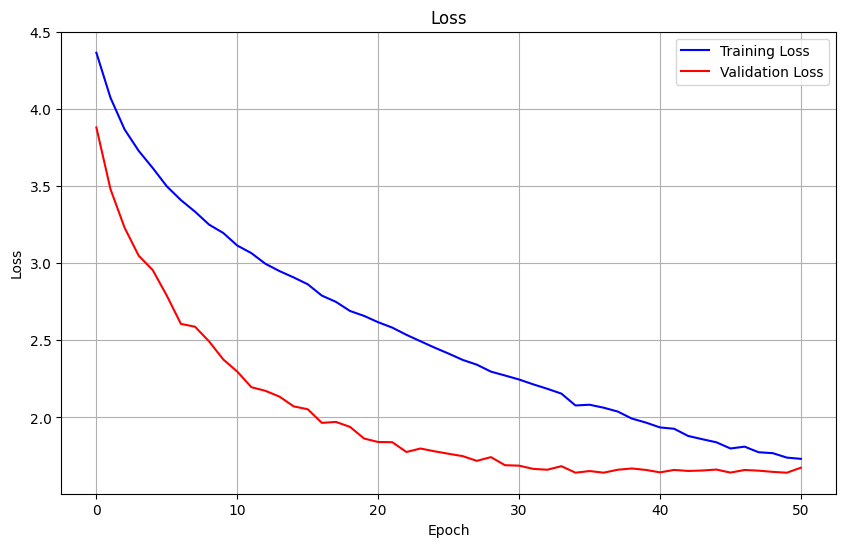

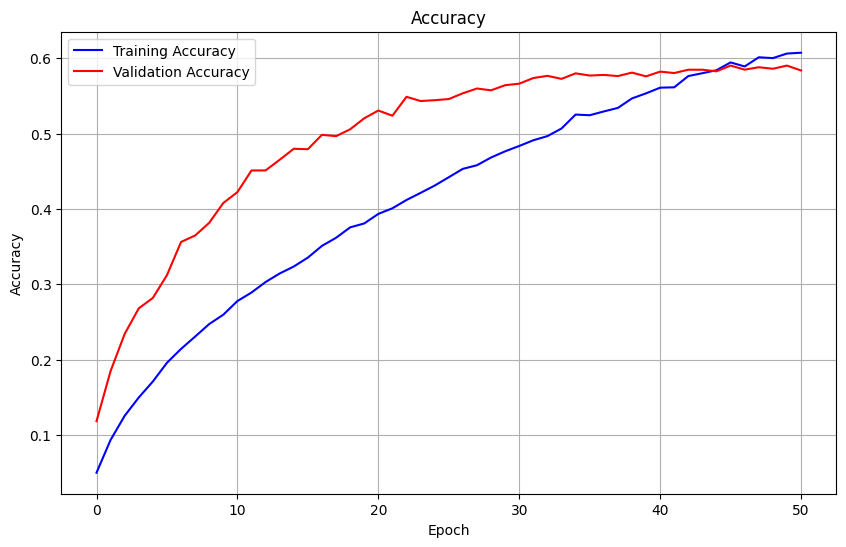

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('history.csv')

def plot_metrics(df, metric, col1, col2, label1, label2):
    plt.figure(figsize=(10,6))
    plt.plot(df.index, df[col1], label=label1, color='blue')
    plt.plot(df.index, df[col2], label=label2, color='red')
    plt.title(metric)
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metrics(df, 'Loss', 'train_loss', 'val_loss', 'Training Loss', 'Validation Loss')
plot_metrics(df, 'Accuracy', 'train_acc', 'val_acc', 'Training Accuracy', 'Validation Accuracy')

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
import numpy as np

def get_preds_and_labels(model, loader):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            probs = torch.softmax(out, dim=1)  
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())  
            all_labels.extend(y.cpu().numpy())

    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

preds, probs, labels = get_preds_and_labels(model, test_loader)
labels_bin = label_binarize(labels, classes=np.unique(labels))
auc = roc_auc_score(labels_bin, probs, multi_class='ovr')

# Residual -- Updated in next block for multi-class roc graphing
class_id = 1
binary_labels = (labels == class_id).astype(int)
fpr, tpr, _ = roc_curve(binary_labels, probs[:, class_id])

f1 = f1_score(labels, preds, average='macro')
precision = precision_score(labels, preds, average='macro')
recall = recall_score(labels, preds, average='macro')

cm = confusion_matrix(labels, preds)
sensitivity_per_class = []
specificity_per_class = []

for i in range(len(cm)):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - (tp + fn + fp)

    sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    sensitivity_per_class.append(sensitivity)
    specificity_per_class.append(specificity)

macro_sensitivity = sum(sensitivity_per_class) / len(sensitivity_per_class)
macro_specificity = sum(specificity_per_class) / len(specificity_per_class)


print(f"AUC: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {macro_sensitivity:.4f}")
print(f"Specificity: {macro_specificity:.4f}")


AUC: 0.9689
F1 Score: 0.5622
Precision: 0.5855
Recall (Sensitivity): 0.5702
Specificity: 0.9957


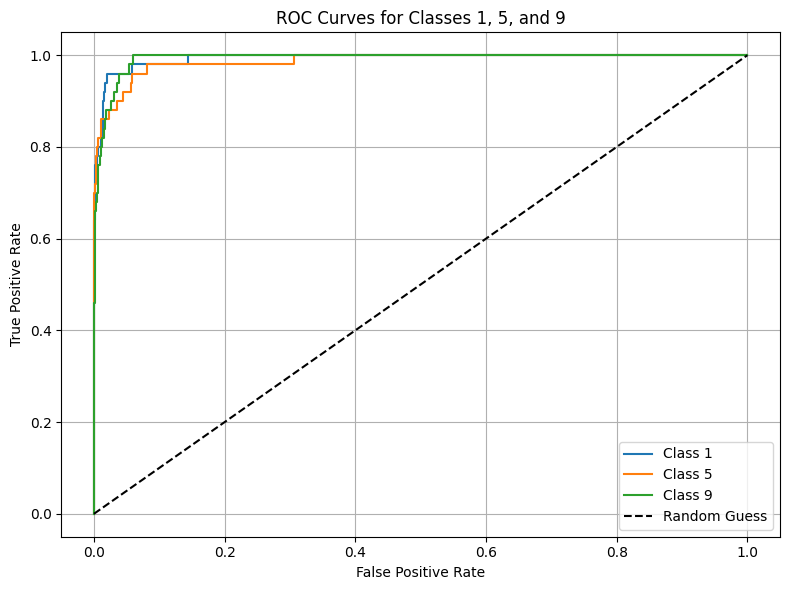

In [12]:
selected_classes = [1, 5, 9]
plt.figure(figsize=(8, 6))

for class_id in selected_classes:
    binary_labels = (labels == class_id).astype(int)
    fpr, tpr, _ = roc_curve(binary_labels, probs[:, class_id])
    plt.plot(fpr, tpr, label=f"Class {class_id}")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classes 1, 5, and 9")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
